In [7]:
import pandas as pd

In [8]:
df = pd.read_csv("customer_data.csv")

In [9]:
df.head()

,age,job,marital,education_qual,call_type,day,mon,dur,num_calls,prev_outcome,y
0,58,management,married,tertiary,unknown,5,may,261,1,unknown,no
1,44,technician,single,secondary,unknown,5,may,151,1,unknown,no
2,33,entrepreneur,married,secondary,unknown,5,may,76,1,unknown,no
3,47,blue-collar,married,unknown,unknown,5,may,92,1,unknown,no
4,33,unknown,single,unknown,unknown,5,may,198,1,unknown,no


In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             45211 non-null  int64
 1   job             45211 non-null  str  
 2   marital         45211 non-null  str  
 3   education_qual  45211 non-null  str  
 4   call_type       45211 non-null  str  
 5   day             45211 non-null  int64
 6   mon             45211 non-null  str  
 7   dur             45211 non-null  int64
 8   num_calls       45211 non-null  int64
 9   prev_outcome    45211 non-null  str  
 10  y               45211 non-null  str  
dtypes: int64(4), str(7)
memory usage: 5.7 MB


In [11]:
df.isnull().sum()

age               0
job               0
marital           0
education_qual    0
call_type         0
day               0
mon               0
dur               0
num_calls         0
prev_outcome      0
y                 0
dtype: int64

In [12]:
df.fillna(0, inplace=True)

,age,job,marital,education_qual,call_type,day,mon,dur,num_calls,prev_outcome,y
0,58,management,married,tertiary,unknown,5,may,261,1,unknown,no
1,44,technician,single,secondary,unknown,5,may,151,1,unknown,no
2,33,entrepreneur,married,secondary,unknown,5,may,76,1,unknown,no
3,47,blue-collar,married,unknown,unknown,5,may,92,1,unknown,no
4,33,unknown,single,unknown,unknown,5,may,198,1,unknown,no
...,...,...,...,...,...,...,...,...,...,...,...
45206,51,technician,married,tertiary,cellular,17,nov,977,3,unknown,yes
45207,71,retired,divorced,primary,cellular,17,nov,456,2,unknown,yes
45208,72,retired,married,secondary,cellular,17,nov,1127,5,success,yes
45209,57,blue-collar,married,secondary,telephone,17,nov,508,4,unknown,no


In [13]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# Convert all text columns
df['job'] = le.fit_transform(df['job'])
df['marital'] = le.fit_transform(df['marital'])
df['education_qual'] = le.fit_transform(df['education_qual'])
df['call_type'] = le.fit_transform(df['call_type'])
df['mon'] = le.fit_transform(df['mon'])
df['prev_outcome'] = le.fit_transform(df['prev_outcome'])
df['y'] = le.fit_transform(df['y'])

# Show updated data
df.head()

,age,job,marital,education_qual,call_type,day,mon,dur,num_calls,prev_outcome,y
0,58,4,1,2,2,5,8,261,1,3,0
1,44,9,2,1,2,5,8,151,1,3,0
2,33,2,1,1,2,5,8,76,1,3,0
3,47,1,1,3,2,5,8,92,1,3,0
4,33,11,2,3,2,5,8,198,1,3,0


In [14]:
# Features (input)
X = df.drop('y', axis=1)

# Target (output)
y = df['y']

print(X.head())
print(y.head())

   age  job  marital  education_qual  call_type  day  mon  dur  num_calls  \
0   58    4        1               2          2    5    8  261          1   
1   44    9        2               1          2    5    8  151          1   
2   33    2        1               1          2    5    8   76          1   
3   47    1        1               3          2    5    8   92          1   
4   33   11        2               3          2    5    8  198          1   

   prev_outcome  
0             3  
1             3  
2             3  
3             3  
4             3  
0    0
1    0
2    0
3    0
4    0
Name: y, dtype: int64


In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(36168, 10)
(9043, 10)


In [16]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

print("Model Trained Successfully")

Model Trained Successfully


In [17]:
predictions = model.predict(X_test)

print(predictions[:10])

[0 0 0 0 0 0 0 0 0 0]


In [19]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, predictions)

print("Accuracy:", accuracy)

Accuracy: 0.8866526595156474


Matplotlib is building the font cache; this may take a moment.


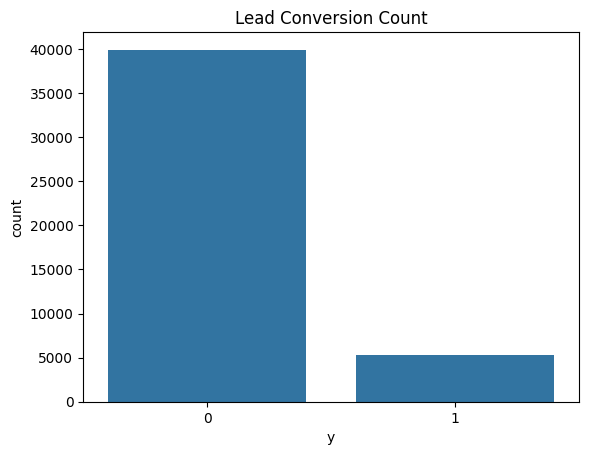

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='y', data=df)

plt.title("Lead Conversion Count")
plt.show()

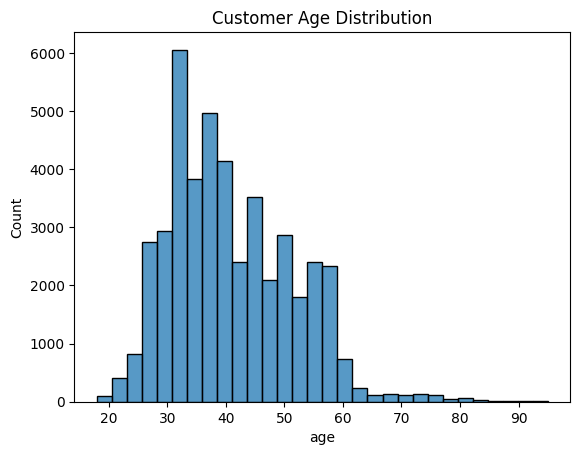

In [21]:
sns.histplot(df['age'], bins=30)

plt.title("Customer Age Distribution")
plt.show()

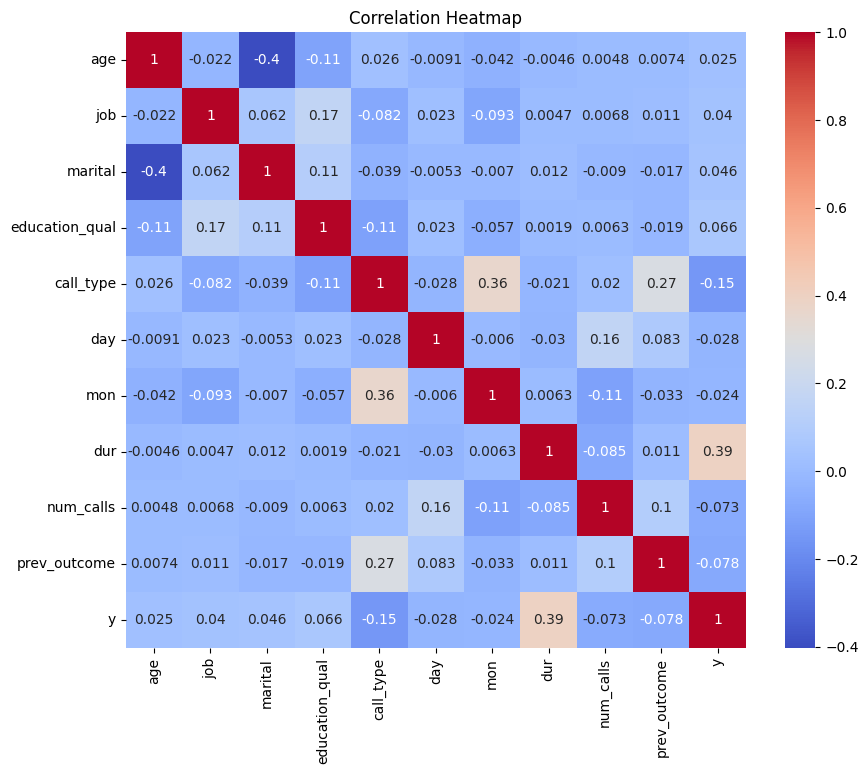

In [22]:
plt.figure(figsize=(10,8))

sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

In [23]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf_model = RandomForestClassifier()

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_predictions)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.9029083268826716


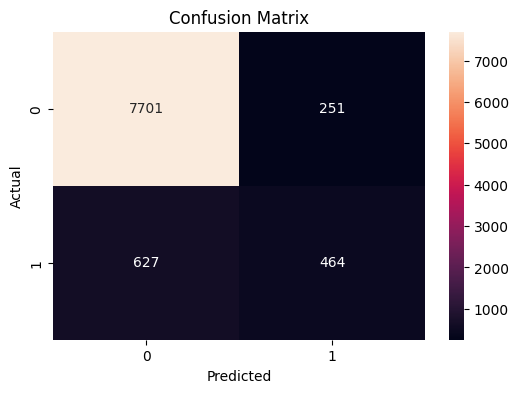

In [24]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, rf_predictions)

plt.figure(figsize=(6,4))

sns.heatmap(cm, annot=True, fmt='d')

plt.title("Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [25]:
from sklearn.metrics import classification_report

print(classification_report(y_test, rf_predictions))

              precision    recall  f1-score   support

           0       0.92      0.97      0.95      7952
           1       0.65      0.43      0.51      1091

    accuracy                           0.90      9043
   macro avg       0.79      0.70      0.73      9043
weighted avg       0.89      0.90      0.89      9043

